In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import warnings

warnings.filterwarnings("ignore")

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [ ]:
df = pd.read_csv("https://media.githubusercontent.com/media/Social-Media-Help-Seeking-ML/yinjasim/refs/heads/main/data/corpus_with_topics.csv")

# filter out the noise -1 topic 
df = df[df['topic'] != -1]

df = df[['id', 'text', 'topic', 'topic_probs', 'topic_name']]

df.to_csv("integration_data.csv", index=False)



In [3]:
def run_integration_pipeline(
    df_integr_set,
    saved_model_path,
):

    tokenizer = AutoTokenizer.from_pretrained(saved_model_path)

    model = AutoModelForSequenceClassification.from_pretrained(saved_model_path)

    max_length = 512

    df_integr_set['text'] = df_integr_set['text'].fillna("").astype(str)

    integr_encodings = tokenizer(
        df_integr_set['text'].tolist(),
        truncation=True,
        padding=True,
        max_length=max_length,
    )

    class InferenceDataset(Dataset):
        def __init__(self, encodings):
            self.encodings = encodings

        def __len__(self):
            return len(self.encodings["input_ids"])

        def __getitem__(self, idx):
            return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

    integr_dataset = InferenceDataset(integr_encodings)

    trainer = Trainer(model=model)

    integr_preds = trainer.predict(integr_dataset)

    integr_logits = integr_preds.predictions

    integr_probs = torch.softmax(torch.tensor(integr_logits), dim=-1).numpy()

    integr_y_pred = np.argmax(integr_probs, axis=1)

    integr_pred_highrisk = np.isin(integr_y_pred, [2, 3]).astype(int)

    integr_prob_highrisk = integr_probs[:, 2] + integr_probs[:, 3]

    integr_prob_severe = integr_probs[:, 3]

    label_id = {
        0: "No Risk",
        1: "Low Risk",
        2: "Moderate Risk",
        3: "Severe Risk",
    }

    if len(df_integr_set) != len(integr_y_pred):
        raise ValueError(
            f"Length mismatch: dataframe has {len(df_integr_set)} rows but predictions have {len(integr_y_pred)} rows."
        )

    df_integr_set["risk_pred_ordinal"] = integr_y_pred

    df_integr_set["risk_pred_label"] = [label_id[i] for i in integr_y_pred]

    df_integr_set["risk_pred_highrisk"] = integr_pred_highrisk

    df_integr_set["risk_prob_highrisk"] = integr_prob_highrisk
    
    df_integr_set["risk_prob_severe"] = integr_prob_severe

    print("Integration dataset shape:", df_integr_set.shape)
    print("\nPredicted ordinal label distribution:")
    print(df_integr_set["risk_pred_label"].value_counts())

    print("\nPredicted HighRisk distribution:")
    print(df_integr_set["risk_pred_highrisk"].value_counts(normalize=True))

    df_integr_set.to_csv('./materials/models_integration/integration_with_risk_predictions.csv', index=False)

    return df_integr_set


In [4]:
df_integr_set = pd.read_csv("integration_data.csv")

df_integration_with_preds = run_integration_pipeline(
    df_integr_set,
    "./roberta_output/checkpoint-455",
)

Integration dataset shape: (34146, 10)

Predicted ordinal label distribution:
risk_pred_label
No Risk          19459
Low Risk         10584
Moderate Risk     3112
Severe Risk        991
Name: count, dtype: int64

Predicted HighRisk distribution:
risk_pred_highrisk
0    0.87984
1    0.12016
Name: proportion, dtype: float64


In [4]:
df = pd.read_csv('./materials/models_integration/integration_with_risk_predictions.csv')

print(df.shape)

df.head()


(34146, 10)


,id,text,topic,topic_probs,topic_name,risk_pred_ordinal,risk_pred_label,risk_pred_highrisk,risk_prob_highrisk,risk_prob_severe
0,rmbbvu,i need some help i have 6 exams in the next 2 ...,25,1.000000,study_assignments_semester_deadline_exams,0,No Risk,0,0.007947,0.002429
1,rmb8lm,Figuring out what to eat sucks Whenever I get ...,8,0.093855,eat_food_eating_meal_foods,0,No Risk,0,0.002975,0.001720
2,rmb6f2,Drinking while on meds? I’m on 20 mg of Lexapr...,3,0.063612,vyvanse_30mg_dose_taking_effects,0,No Risk,0,0.003718,0.001771
3,rmb2i8,Does everyone get the euphoria feeling when th...,5,1.000000,adderall_xr_ir_dose_taking,0,No Risk,0,0.002643,0.001529
4,rmb1ib,Xaggatin: zoned out and angry TL;DR - rough ti...,142,0.037301,methylphenidate_dose_36mg_meds_18mg,1,Low Risk,0,0.018468,0.002095


### Top 15 Topics by Mean Risk

In [5]:
df = pd.read_csv('./materials/models_integration/integration_with_risk_predictions.csv')

df["risk_pred_ordinal"] = df["risk_pred_ordinal"].astype(int)

df["topic_name"] = df["topic_name"].str.replace("_", ", ")

df["topic_label"] = (
    df["topic"].astype(str) + " | " + df["topic_name"].astype(str)
)

# count topic risk
topic_risk_counts = (
    df
    .groupby(["topic_label", "risk_pred_ordinal"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
)

# get topic risk proportion

topic_risk_props = topic_risk_counts.div(topic_risk_counts.sum(axis=1), axis=0)

# weighted average for topic ranking
topic_risk_props["mean_risk"] = (
    topic_risk_props[0] * 0 +
    topic_risk_props[1] * 1 +
    topic_risk_props[2] * 2 +
    topic_risk_props[3] * 3
)

df = topic_risk_props.sort_values("mean_risk", ascending=False)

df = df.reset_index("topic_label")

df = df.set_index(["topic_label", "mean_risk"])

df.columns = ["No Risk", "Low Risk", "Moderate Risk", "Severe Risk"]

topic_risk_props = df.copy()

df

,,No Risk,Low Risk,Moderate Risk,Severe Risk
topic_label,mean_risk,,,,
"136 | suicide, die, tired, kill, shit",2.771930,0.000000,0.017544,0.192982,0.789474
"356 | die, suicidal, anymore, family, hate",2.450000,0.000000,0.000000,0.550000,0.450000
"149 | anymore, myself, die, pain, family",2.420000,0.000000,0.000000,0.580000,0.420000
"2 | die, kill, want, suicide, life",2.387057,0.021978,0.105006,0.336996,0.536020
"143 | family, life, want, anymore, no",2.365385,0.000000,0.057692,0.519231,0.423077
...,...,...,...,...,...
"470 | blink, blinking, twitch, muscle, twitches",0.000000,1.000000,0.000000,0.000000,0.000000
"473 | ep, ups, inspire, push, ptsd",0.000000,1.000000,0.000000,0.000000,0.000000
"344 | book, autism, autistic, books, neurotribes",0.000000,1.000000,0.000000,0.000000,0.000000


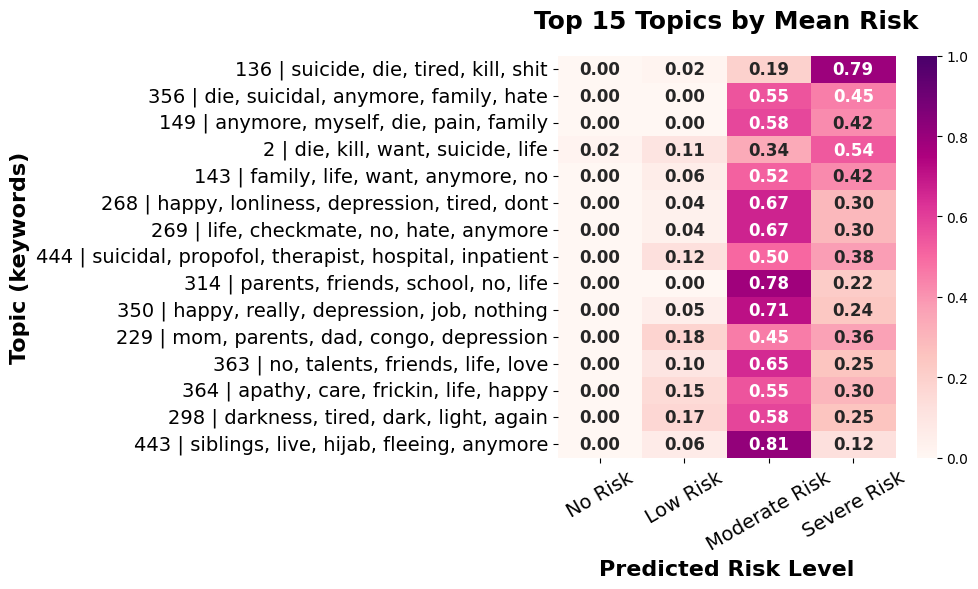

In [ ]:
df = topic_risk_props.copy()

top_k = 15

df = df.reset_index()

df = df.sort_values("mean_risk", ascending=False).head(top_k)

df = df.drop(columns="mean_risk")

df = df.set_index(["topic_label"])

plt.figure(figsize=(10, 6))

sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap='RdPu',
    vmin=0,
    vmax=1,
    annot_kws={"size": 12, "weight": "bold"},
)

plt.title("Top 15 Topics by Mean Risk", fontsize=18, fontweight="bold", pad=20)
plt.xticks(fontsize=14, rotation=30)
plt.yticks(fontsize=14, )
plt.xlabel("Predicted Risk Level", fontsize=16, fontweight="bold")
plt.ylabel("Topic (keywords)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"./materials/saved_images/Topics_by_Mean_Risk.png", dpi=300, bbox_inches="tight")
plt.show()

### Topic Prevalence Over Time

In [7]:
df = pd.read_csv("./materials/models_integration/figure_data_topic_prevalence_over_time.csv")

df["month"] = pd.to_datetime(df["month"])

df["year_month"] = df["month"].dt.strftime("%Y-%m")

df = df[df["topic_id"] != -1].dropna()

df_topic_preval = df.copy()

df

,month,topic_id,post_count,keywords_from_name_top4,in_top10_stack,stack_order_in_figure,plot_color_hex,year_month
30,2019-07-01,0,3,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-07
31,2019-08-01,0,3,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-08
32,2019-09-01,0,11,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-09
33,2019-10-01,0,8,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-10
34,2019-11-01,0,8,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-11
...,...,...,...,...,...,...,...,...
325,2021-08-01,9,15,"work, time, app, things",True,10.0,#E76F51,2021-08
326,2021-09-01,9,15,"work, time, app, things",True,10.0,#E76F51,2021-09
327,2021-10-01,9,157,"work, time, app, things",True,10.0,#E76F51,2021-10
328,2021-11-01,9,178,"work, time, app, things",True,10.0,#E76F51,2021-11


In [8]:
df = df_topic_preval.copy()

df = df[df["topic_id"] != -1].dropna()

df

,month,topic_id,post_count,keywords_from_name_top4,in_top10_stack,stack_order_in_figure,plot_color_hex,year_month
30,2019-07-01,0,3,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-07
31,2019-08-01,0,3,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-08
32,2019-09-01,0,11,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-09
33,2019-10-01,0,8,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-10
34,2019-11-01,0,8,"adderall, taking, vyvanse, meds",True,1.0,#E69F00,2019-11
...,...,...,...,...,...,...,...,...
325,2021-08-01,9,15,"work, time, app, things",True,10.0,#E76F51,2021-08
326,2021-09-01,9,15,"work, time, app, things",True,10.0,#E76F51,2021-09
327,2021-10-01,9,157,"work, time, app, things",True,10.0,#E76F51,2021-10
328,2021-11-01,9,178,"work, time, app, things",True,10.0,#E76F51,2021-11


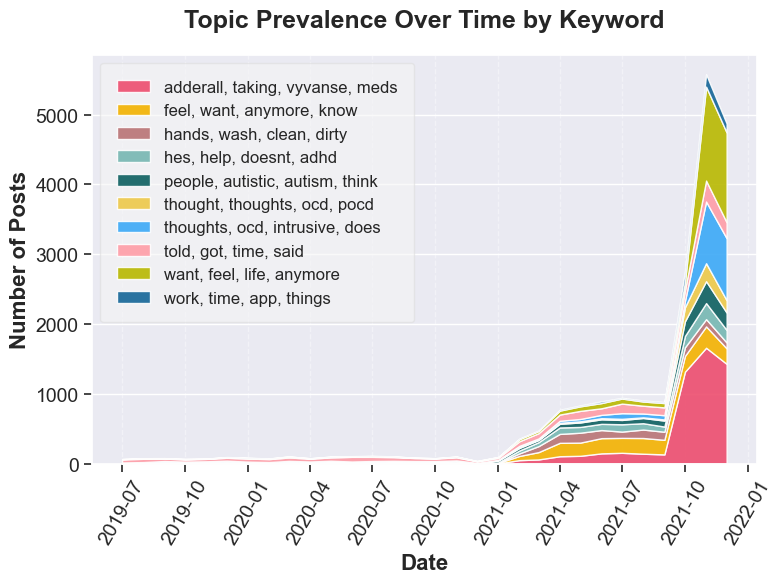

In [ ]:
df = df_topic_preval.copy()

sns.set_theme(style="darkgrid")

colors = ["#ed4d6e", "#f3b200", "#b97375", "#76B7B2", "#0d5f60", "#EDC948", "#3ba9f7", "#FF9DA7", "#b8b800", "#146597"]

plt.figure(figsize=(8, 6))
df_pivot = df.pivot(index="month", columns="keywords_from_name_top4", values="post_count").fillna(0)

plt.stackplot(
    df_pivot.index,
    df_pivot.T,
    labels=df_pivot.columns,
    colors=colors,
    alpha=0.9,
)

plt.xticks(fontsize=14, rotation=60)
plt.yticks(fontsize=14)
plt.legend(loc="upper left", facecolor="#f5f5f5", edgecolor="#dddddd", fontsize=12, framealpha=0.6, borderpad=1)

plt.title("Topic Prevalence Over Time by Keyword", fontsize=18, fontweight="bold", pad=20)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tick_params(axis="both", which="major", bottom=True, left=True, length=6, width=1.2, direction="out")

plt.xlabel("Date", fontsize=16, fontweight="bold")
plt.ylabel("Number of Posts", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(f"./materials/saved_images/Topic_Prevalence_Over_Time.png", dpi=300, bbox_inches="tight")
plt.show()

References:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.stackplot.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

https://huggingface.co/docs/transformers/en/model_doc/roberta

https://seaborn.pydata.org/generated/seaborn.heatmap.html